*Предположение: коэффициент $\alpha$ один на весь детектор*

**План работ:**
- функция маскирования чет/нечет;
- функция оценки $\hat{\alpha}$;

**Тестирование:**
- $\hat{\alpha} - \alpha$ в идеальных условиях;
- $\hat{\alpha} - \alpha$ при наличие шума;
- $\hat{\alpha} - \alpha$ при наличие шума и спектральных линий;


In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R
from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

In [2]:
N_NUMBERS = 2048
N_FRAMES = 1
N_ITERS = 251

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

In [3]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)
    
    # add background
    value = intensity + background

    # add event/odd
    number = np.arange(len(intensity))

    index_even = number % 2 == 0
    value[index_even] = value[index_even] * (1 - alpha/2)

    index_odd = number % 2 == 1
    value[index_odd] = value[index_odd] * (1 + alpha/2)

    #
    return value

In [4]:
detector = Detector.BLPP2000

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        # position=np.linspace(0, N_NUMBERS, N_ITERS),
        # intensity=np.full(N_ITERS, 1),
        position=np.random.uniform(0, N_NUMBERS, size=(N_ITERS,)),
        intensity=10**np.random.normal(MU, SIGMA, size=(N_ITERS,)),
    ),
)
experiment = experiment.setup(
    verbose=True,
)

100%|██████████| 251/251 [00:00<00:00, 11555.82it/s]


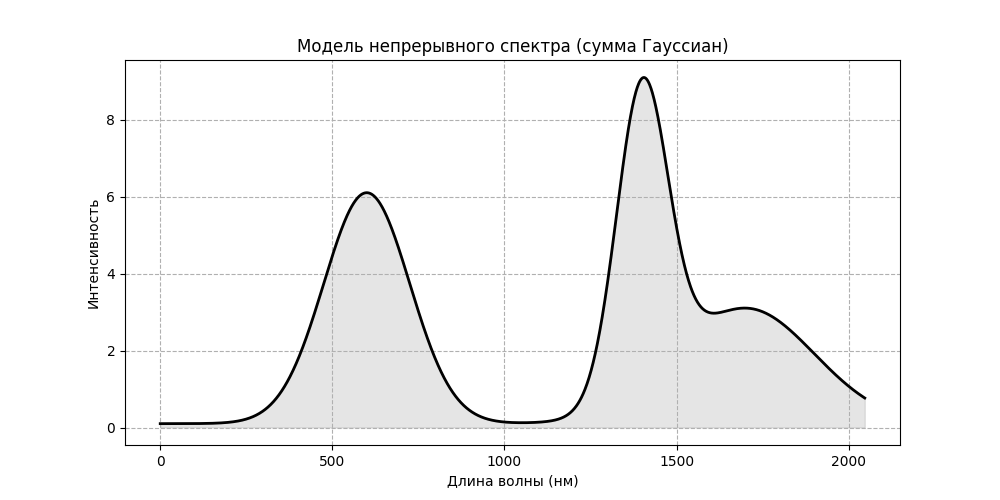

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# number = np.linspace(400, 800, 1000)  # например, нанометры
number = np.arange(N_NUMBERS)

params = [
    {"A": 10, "mu": 2500, "sigma": 75},
    {"A": 6, "mu": 600, "sigma": 125},
    {"A": 8, "mu": 1400, "sigma": 75},
    {"A": 3, "mu": 1700, "sigma": 200},
]

background = np.zeros_like(number) + .1

for p in params:
    line = p["A"] * np.exp(-((number - p["mu"])**2) / (2 * p["sigma"]**2))
    background += line

# spectrum[index_even] = spectrum[index_even] * (1 + alpha/2)
# spectrum[index_odd] = spectrum[index_odd] * (1 - alpha/2)


plt.figure(figsize=(10, 5))
plt.plot(number, background, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(number, background, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()


100%|██████████| 251/251 [00:00<00:00, 10103.26it/s]


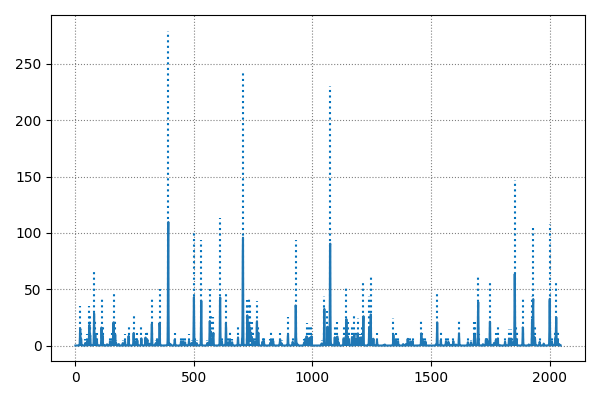

In [28]:
experiment = experiment.setup(
    seed=42,
    verbose=True,
    show=True,
)

In [29]:
unicorn = experiment.run(
    is_noised=False,
    transformer=partial(transformer, alpha=0, background=background),
)

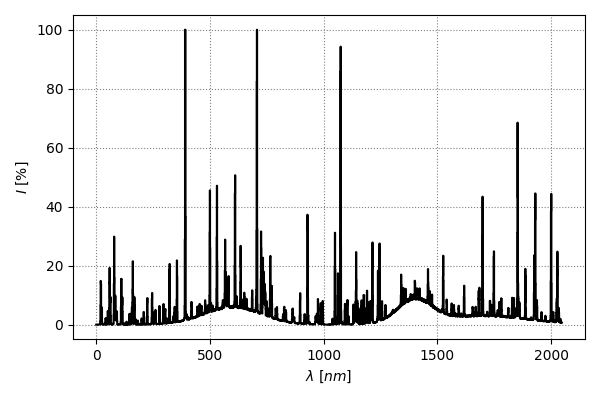

In [36]:
alpha = .042 * 2

spectrum = experiment.run(
    is_noised=True,
    transformer=partial(transformer, alpha=alpha, background=background),
)
spectrum.show()

In [37]:
peaks = draft_blinks(
    spectrum=spectrum,
    config=DraftBlinksConfig(
        n_counts_min=5,
        except_clipped_peak=False,
        except_sloped_peak=False,
        except_edges=True,
    ),
)

print('Praks total: {}'.format(len(peaks)))

Praks total: 160


In [49]:
mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub] = False


alpha_hat = estimate_alpha(
    spectrum=spectrum,
    mask=mask,
)
# alpha_hat = 0

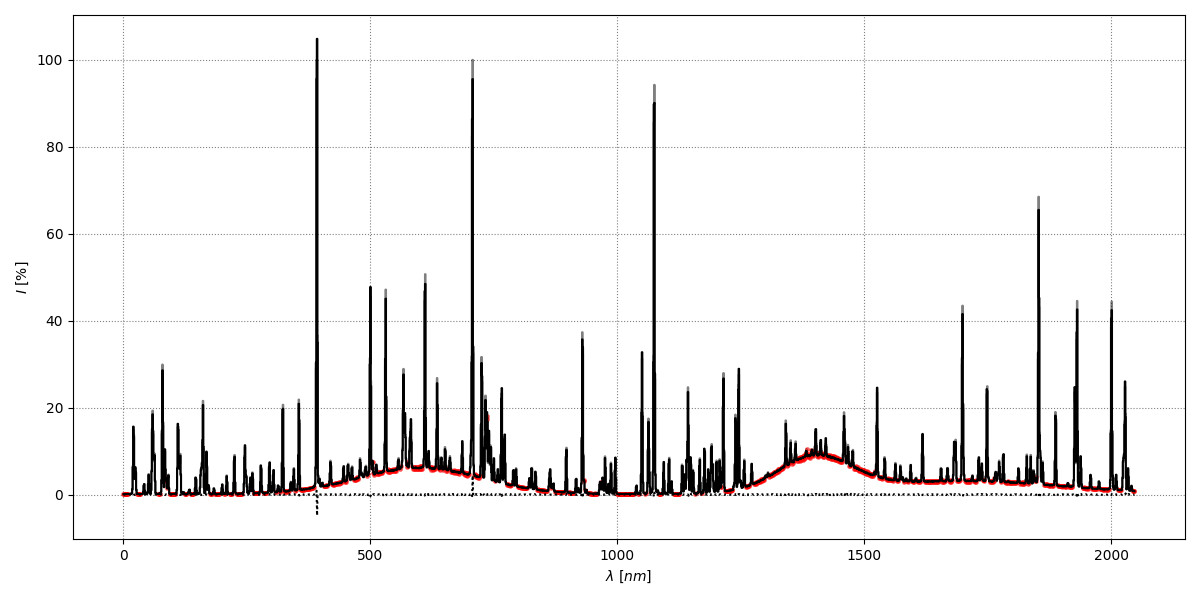

In [50]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

x = spectrum.wavelength
y = spectrum.intensity
ax.step(
    x, y,
    where='mid',
    color='black', alpha=.5,
)

x = spectrum.wavelength[mask]
y = spectrum.intensity[mask]
ax.plot(
    x, y,
    linestyle='none', color='red', alpha=.5,
    marker='.', markersize=5,
    label='$s_{k}$',
)

x = spectrum.wavelength
intensity_scaled = spectrum.intensity.copy()
intensity_scaled[0::2] /= 1 - alpha_hat/2
intensity_scaled[1::2] /= 1 + alpha_hat/2
y_hat = intensity_scaled
ax.step(
    x, y_hat,
    where='mid',
    color='black',
)

x = spectrum.wavelength
y = unicorn.intensity - y_hat
ax.plot(
    x, y,
    linestyle=':',
    color='black',
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)


In [45]:
alpha_hat, alpha

(0, 0.084)

In [46]:
100 * (alpha_hat - alpha) / alpha

-100.0